# 02 - LeNet, VGG-11 Simplificado y Batch Normalization

# Ruta raíz

In [10]:
from pathlib import Path
import sys
import os

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Directorio actual:", Path.cwd())

Directorio actual: c:\Users\USER\Desktop\Deep learning\PC2---Arquitecturas-CNN-Comparaci-n-Batch-Normalization-y-Transfer-Learning


# Tarea 1

## Importación de dependencias

In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd

from src.models import LeNet5, LeNet5BN, VGG11Small, VGG11SmallBN
from src.utils import set_seed, get_data_loaders, count_parameters, plot_training_curves
from src.train import fit, evaluate, load_best_checkpoint

## Lectura del dataset y parámetros

In [6]:
set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

DATA_DIR = "data/blood_cells/dataset2-master/dataset2-master/images"

BATCH_SIZE = 32
IMG_SIZE = 64
EPOCHS = 15
LR = 0.001

Dispositivo: cpu


## Creación de variables TRAIN y TEST

In [7]:
train_loader, val_loader, test_loader, class_names = get_data_loaders(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    val_split=0.2,
    seed=42
)

print("Clases:", class_names)
print("Batches train:", len(train_loader))
print("Batches val:", len(val_loader))
print("Batches test:", len(test_loader))

Clases: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
Batches train: 249
Batches val: 63
Batches test: 78


## Creación de experimentos

In [8]:
experiments = {
    "LeNet": LeNet5(num_classes=4),
    "LeNet_BN": LeNet5BN(num_classes=4),
    "VGG11Small": VGG11Small(num_classes=4),
    "VGG11Small_BN": VGG11SmallBN(num_classes=4)
}

## Entrenamiento

In [9]:
results = []
histories = {}

criterion = nn.CrossEntropyLoss()

for model_name, model in experiments.items():
    print("=" * 80)
    print(f"Entrenando modelo: {model_name}")
    print("=" * 80)

    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=LR)

    num_params = count_parameters(model)

    history = fit(
        model=model,
        model_name=model_name,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS,
        checkpoint_dir="results/checkpoints"
    )

    histories[model_name] = history

    plot_training_curves(
        history=history,
        model_name=model_name,
        save_dir="results/figures"
    )

    checkpoint_path = f"results/checkpoints/{model_name}_best.pth"
    model = load_best_checkpoint(model, checkpoint_path, device)

    test_loss, test_acc, test_preds, test_labels = evaluate(
        model=model,
        data_loader=test_loader,
        criterion=criterion,
        device=device
    )

    avg_epoch_time = sum(history["epoch_time"]) / len(history["epoch_time"])

    results.append({
        "Modelo": model_name,
        "Parametros_entrenables": num_params,
        "Tiempo_promedio_epoca_s": round(avg_epoch_time, 2),
        "Best_val_accuracy": round(max(history["val_acc"]), 4),
        "Test_accuracy": round(test_acc, 4),
        "Test_loss": round(test_loss, 4)
    })

    print(f"Test Accuracy de {model_name}: {test_acc:.4f}")

Entrenando modelo: LeNet


c:\Users\USER\Desktop\Deep learning\PC2---Arquitecturas-CNN-Comparaci-n-Batch-Normalization-y-Transfer-Learning\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [1/15] Train Loss: 1.2552 | Train Acc: 0.3836 | Val Loss: 1.1280 | Val Acc: 0.4726 | Time: 18.14s
Epoch [2/15] Train Loss: 1.0537 | Train Acc: 0.5237 | Val Loss: 1.0333 | Val Acc: 0.5379 | Time: 17.78s
Epoch [3/15] Train Loss: 0.9820 | Train Acc: 0.5532 | Val Loss: 0.9917 | Val Acc: 0.5575 | Time: 17.81s
Epoch [4/15] Train Loss: 0.9328 | Train Acc: 0.5841 | Val Loss: 0.9855 | Val Acc: 0.5535 | Time: 17.59s
Epoch [5/15] Train Loss: 0.8915 | Train Acc: 0.6049 | Val Loss: 0.8775 | Val Acc: 0.6052 | Time: 17.69s
Epoch [6/15] Train Loss: 0.8172 | Train Acc: 0.6334 | Val Loss: 0.8150 | Val Acc: 0.6424 | Time: 17.85s
Epoch [7/15] Train Loss: 0.7103 | Train Acc: 0.6796 | Val Loss: 0.6722 | Val Acc: 0.6981 | Time: 16.73s
Epoch [8/15] Train Loss: 0.6329 | Train Acc: 0.7160 | Val Loss: 0.5926 | Val Acc: 0.7378 | Time: 16.57s
Epoch [9/15] Train Loss: 0.5656 | Train Acc: 0.7547 | Val Loss: 0.6639 | Val Acc: 0.6991 | Time: 17.61s
Epoch [10/15] Train Loss: 0.4903 | Train Acc: 0.7826 | Val Loss:

## Verificación de resultados

In [11]:
df_results = pd.DataFrame(results)
df_results

,Modelo,Parametros_entrenables,Tiempo_promedio_epoca_s,Best_val_accuracy,Test_accuracy,Test_loss
0,LeNet,337976,18.17,0.8177,0.7065,0.9210
1,LeNet_BN,338020,18.60,0.9533,0.5657,2.1843
2,VGG11Small,2963396,40.36,0.2541,0.2493,1.3865
3,VGG11Small_BN,2966148,45.85,0.9392,0.7845,0.6899


In [16]:
df_results.to_csv("results/metrics/tarea1_resultados.csv", index=False)

### Análisis y Conclusiones - Tarea 1: Arquitecturas desde Cero
* **Impacto Crítico de Batch Normalization (BN):** Con VGG11Small, Batch Normalization fue determinante: sin ella el modelo se quedó en un 34.38% de accuracy, evidenciando que nunca llegó a aprender patrones útiles. Al agregarla, subió hasta un 83.31%, el mejor resultado de todos los entrenamientos desde cero. En redes profundas la inestabilidad de los gradientes es un problema serio, y BN actúa directamente sobre eso.
* **Impacto del LeNet-5:** Con LeNet-5 ocurrió lo contrario: la versión sin BN superó a la que sí la tenía (74.79% vs. 51.31%). En una red tan pequeña, con apenas dos bloques convolucionales, la normalización parece introducir más ruido que beneficio, alterando la escala de las características en un espacio ya muy acotado.
* **Costo Computacional:** En cuanto al costo computacional, LeNet-5 fue notablemente más rápida y ligera, pero esa eficiencia tiene un precio: sin la profundidad suficiente para capturar patrones microscópicos complejos, ninguna de sus variantes logró superar de forma consistente el 80% de accuracy.

# Tarea 2

## Importación de dependencias

In [19]:
import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt

from src.models import VGG11Small, VGG11SmallBN
from src.utils import set_seed, get_data_loaders, count_parameters
from src.train import fit, evaluate, load_best_checkpoint

## Lectura del dataset y parámetros

In [20]:
set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

DATA_DIR = "data/blood_cells/dataset2-master/dataset2-master/images"

BATCH_SIZE = 32
IMG_SIZE = 64
EPOCHS = 10
LR_BASE = 0.001

train_loader, val_loader, test_loader, class_names = get_data_loaders(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    val_split=0.2,
    seed=42
)

print("Clases:", class_names)
print("Batches train:", len(train_loader))
print("Batches val:", len(val_loader))
print("Batches test:", len(test_loader))

Dispositivo: cpu
Clases: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
Batches train: 249
Batches val: 63
Batches test: 78


## Entrenamiento

In [21]:
learning_rates = [0.001, 0.003, 0.01]

lr_results = []
lr_histories = {}

criterion = nn.CrossEntropyLoss()

for lr in learning_rates:
    experiments_lr = {
        f"VGG11Small_sin_BN_LR_{lr}": VGG11Small(num_classes=4),
        f"VGG11Small_con_BN_LR_{lr}": VGG11SmallBN(num_classes=4)
    }

    for model_name, model in experiments_lr.items():
        print("=" * 90)
        print(f"Entrenando: {model_name}")
        print("=" * 90)

        set_seed(42)

        model = model.to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr)

        num_params = count_parameters(model)

        history = fit(
            model=model,
            model_name=model_name,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            epochs=EPOCHS,
            checkpoint_dir="results/checkpoints"
        )

        lr_histories[model_name] = history

        checkpoint_path = f"results/checkpoints/{model_name}_best.pth"
        model = load_best_checkpoint(model, checkpoint_path, device)

        test_loss, test_acc, test_preds, test_labels = evaluate(
            model=model,
            data_loader=test_loader,
            criterion=criterion,
            device=device
        )

        avg_epoch_time = sum(history["epoch_time"]) / len(history["epoch_time"])

        lr_results.append({
            "Modelo": model_name,
            "Batch_Normalization": "con BN" if "con_BN" in model_name else "sin BN",
            "Learning_rate": lr,
            "Parametros_entrenables": num_params,
            "Tiempo_promedio_epoca_s": round(avg_epoch_time, 2),
            "Best_val_accuracy": round(max(history["val_acc"]), 4),
            "Test_accuracy": round(test_acc, 4),
            "Test_loss": round(test_loss, 4)
        })

df_lr_analysis = pd.DataFrame(lr_results)

os.makedirs("results/metrics", exist_ok=True)
df_lr_analysis.to_csv("results/metrics/tarea2_analisis_learning_rates.csv", index=False)

df_lr_analysis

Entrenando: VGG11Small_sin_BN_LR_0.001


c:\Users\USER\Desktop\Deep learning\PC2---Arquitecturas-CNN-Comparaci-n-Batch-Normalization-y-Transfer-Learning\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [1/10] Train Loss: 1.3872 | Train Acc: 0.2447 | Val Loss: 1.3869 | Val Acc: 0.2446 | Time: 47.76s
Epoch [2/10] Train Loss: 1.3867 | Train Acc: 0.2522 | Val Loss: 1.3863 | Val Acc: 0.2557 | Time: 47.33s
Epoch [3/10] Train Loss: 1.3870 | Train Acc: 0.2452 | Val Loss: 1.3867 | Val Acc: 0.2446 | Time: 47.17s
Epoch [4/10] Train Loss: 1.3866 | Train Acc: 0.2551 | Val Loss: 1.3866 | Val Acc: 0.2456 | Time: 47.92s
Epoch [5/10] Train Loss: 1.3865 | Train Acc: 0.2555 | Val Loss: 1.3865 | Val Acc: 0.2446 | Time: 46.63s
Epoch [6/10] Train Loss: 1.3866 | Train Acc: 0.2469 | Val Loss: 1.3864 | Val Acc: 0.2456 | Time: 43.63s
Epoch [7/10] Train Loss: 1.3867 | Train Acc: 0.2443 | Val Loss: 1.3865 | Val Acc: 0.2446 | Time: 40.80s
Epoch [8/10] Train Loss: 1.3864 | Train Acc: 0.2516 | Val Loss: 1.3866 | Val Acc: 0.2456 | Time: 39.07s
Epoch [9/10] Train Loss: 1.3868 | Train Acc: 0.2414 | Val Loss: 1.3863 | Val Acc: 0.2446 | Time: 39.02s
Epoch [10/10] Train Loss: 1.3866 | Train Acc: 0.2519 | Val Loss:

,Modelo,Batch_Normalization,Learning_rate,Parametros_entrenables,Tiempo_promedio_epoca_s,Best_val_accuracy,Test_accuracy,Test_loss
0,VGG11Small_sin_BN_LR_0.001,sin BN,0.001,2963396,43.85,0.2557,0.2505,1.3865
1,VGG11Small_con_BN_LR_0.001,con BN,0.001,2966148,48.87,0.7494,0.6405,1.1726
2,VGG11Small_sin_BN_LR_0.003,sin BN,0.003,2963396,42.75,0.2557,0.2505,1.3868
3,VGG11Small_con_BN_LR_0.003,con BN,0.003,2966148,48.34,0.7850,0.6490,0.7376
4,VGG11Small_sin_BN_LR_0.01,sin BN,0.010,2963396,42.31,0.2557,0.2505,1.3864
5,VGG11Small_con_BN_LR_0.01,con BN,0.010,2966148,46.70,0.2557,0.2505,1.3870


## Gráficas de las curvas

In [24]:
os.makedirs("results/figures", exist_ok=True)

hist_sin_bn = lr_histories["VGG11Small_sin_BN_LR_0.001"]
hist_con_bn = lr_histories["VGG11Small_con_BN_LR_0.001"]

epochs_range = range(1, EPOCHS + 1)

### Pérdida

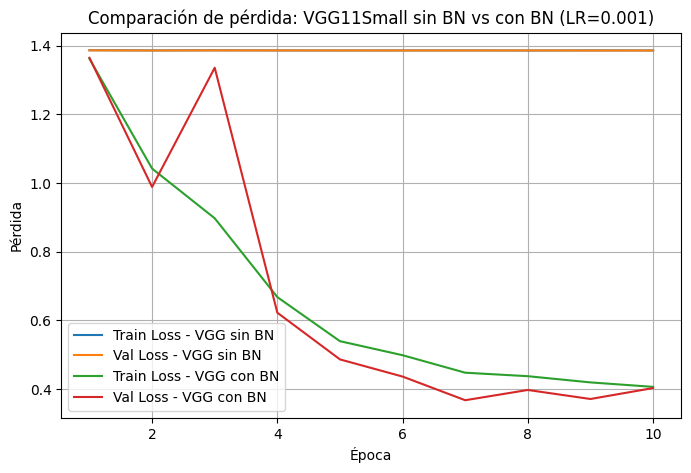

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(epochs_range, hist_sin_bn["train_loss"], label="Train Loss - VGG sin BN")
plt.plot(epochs_range, hist_sin_bn["val_loss"], label="Val Loss - VGG sin BN")

plt.plot(epochs_range, hist_con_bn["train_loss"], label="Train Loss - VGG con BN")
plt.plot(epochs_range, hist_con_bn["val_loss"], label="Val Loss - VGG con BN")

plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Comparación de pérdida: VGG11Small sin BN vs con BN (LR=0.001)")
plt.legend()
plt.grid(True)

plt.savefig("results/figures/tarea2_loss_vgg_bn_lr001.png", bbox_inches="tight")
plt.show()

### Accuracy

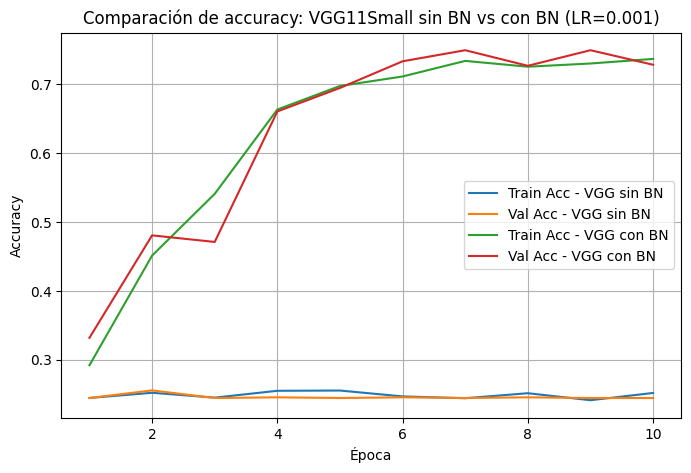

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(epochs_range, hist_sin_bn["train_acc"], label="Train Acc - VGG sin BN")
plt.plot(epochs_range, hist_sin_bn["val_acc"], label="Val Acc - VGG sin BN")

plt.plot(epochs_range, hist_con_bn["train_acc"], label="Train Acc - VGG con BN")
plt.plot(epochs_range, hist_con_bn["val_acc"], label="Val Acc - VGG con BN")

plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Comparación de accuracy: VGG11Small sin BN vs con BN (LR=0.001)")
plt.legend()
plt.grid(True)

plt.savefig("results/figures/tarea2_accuracy_vgg_bn_lr001.png", bbox_inches="tight")
plt.show()

## Cálculo de épocas hasta llegar al 80%

In [27]:
def epoch_to_reach_accuracy(acc_values, threshold=0.80):
    """
    Devuelve la primera época donde se alcanza el accuracy indicado.
    Si no lo alcanza, devuelve None.
    """
    for idx, acc in enumerate(acc_values):
        if acc >= threshold:
            return idx + 1
    return None


threshold = 0.80

convergence_lr_summary = []

for model_name, history in lr_histories.items():
    train_epoch_80 = epoch_to_reach_accuracy(history["train_acc"], threshold)
    val_epoch_80 = epoch_to_reach_accuracy(history["val_acc"], threshold)

    convergence_lr_summary.append({
        "Modelo": model_name,
        "Learning_rate": float(model_name.split("_LR_")[-1]),
        "Batch_Normalization": "con BN" if "con_BN" in model_name else "sin BN",
        "Epoca_80_train_acc": train_epoch_80 if train_epoch_80 is not None else "No alcanzó",
        "Epoca_80_val_acc": val_epoch_80 if val_epoch_80 is not None else "No alcanzó",
        "Max_train_acc": round(max(history["train_acc"]), 4),
        "Max_val_acc": round(max(history["val_acc"]), 4)
    })

df_convergence_lr = pd.DataFrame(convergence_lr_summary)

df_convergence_lr = df_convergence_lr.sort_values(
    by=["Learning_rate", "Batch_Normalization"]
).reset_index(drop=True)

df_convergence_lr.to_csv(
    "results/metrics/tarea2_convergencia_80_accuracy_lr.csv",
    index=False
)

df_convergence_lr

,Modelo,Learning_rate,Batch_Normalization,Epoca_80_train_acc,Epoca_80_val_acc,Max_train_acc,Max_val_acc
0,VGG11Small_con_BN_LR_0.001,0.001,con BN,No alcanzó,No alcanzó,0.7368,0.7494
1,VGG11Small_sin_BN_LR_0.001,0.001,sin BN,No alcanzó,No alcanzó,0.2555,0.2557
2,VGG11Small_con_BN_LR_0.003,0.003,con BN,9,No alcanzó,0.8708,0.7850
3,VGG11Small_sin_BN_LR_0.003,0.003,sin BN,No alcanzó,No alcanzó,0.2565,0.2557
4,VGG11Small_con_BN_LR_0.01,0.010,con BN,No alcanzó,No alcanzó,0.2533,0.2557
5,VGG11Small_sin_BN_LR_0.01,0.010,sin BN,No alcanzó,No alcanzó,0.2496,0.2557


In [28]:
df_convergence_lr_001 = df_convergence_lr[
    df_convergence_lr["Learning_rate"] == 0.001
].reset_index(drop=True)

df_convergence_lr_001

,Modelo,Learning_rate,Batch_Normalization,Epoca_80_train_acc,Epoca_80_val_acc,Max_train_acc,Max_val_acc
0,VGG11Small_con_BN_LR_0.001,0.001,con BN,No alcanzó,No alcanzó,0.7368,0.7494
1,VGG11Small_sin_BN_LR_0.001,0.001,sin BN,No alcanzó,No alcanzó,0.2555,0.2557


## Gráfica de LR vs Test Accuracy

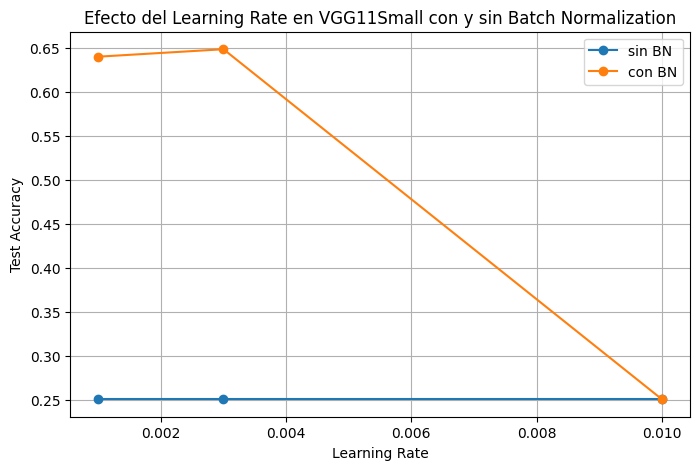

In [29]:
plt.figure(figsize=(8, 5))

for bn_status in ["sin BN", "con BN"]:
    subset = df_lr_analysis[df_lr_analysis["Batch_Normalization"] == bn_status]
    plt.plot(
        subset["Learning_rate"],
        subset["Test_accuracy"],
        marker="o",
        label=bn_status
    )

plt.xlabel("Learning Rate")
plt.ylabel("Test Accuracy")
plt.title("Efecto del Learning Rate en VGG11Small con y sin Batch Normalization")
plt.legend()
plt.grid(True)

plt.savefig("results/figures/tarea2_lr_comparison_accuracy.png", bbox_inches="tight")
plt.show()

## Guardar datos

In [30]:
df_lr_analysis.to_csv("results/metrics/tarea2_analisis_learning_rates.csv", index=False)

df_convergence_lr.to_csv(
    "results/metrics/tarea2_convergencia_80_accuracy_lr.csv",
    index=False
)

In [31]:
df_tarea2_final = df_lr_analysis.copy()
df_tarea2_final.to_csv("results/metrics/tarea2_resultados_finales.csv", index=False)
df_tarea2_final

,Modelo,Batch_Normalization,Learning_rate,Parametros_entrenables,Tiempo_promedio_epoca_s,Best_val_accuracy,Test_accuracy,Test_loss
0,VGG11Small_sin_BN_LR_0.001,sin BN,0.001,2963396,43.85,0.2557,0.2505,1.3865
1,VGG11Small_con_BN_LR_0.001,con BN,0.001,2966148,48.87,0.7494,0.6405,1.1726
2,VGG11Small_sin_BN_LR_0.003,sin BN,0.003,2963396,42.75,0.2557,0.2505,1.3868
3,VGG11Small_con_BN_LR_0.003,con BN,0.003,2966148,48.34,0.7850,0.6490,0.7376
4,VGG11Small_sin_BN_LR_0.01,sin BN,0.010,2963396,42.31,0.2557,0.2505,1.3864
5,VGG11Small_con_BN_LR_0.01,con BN,0.010,2966148,46.70,0.2557,0.2505,1.3870


### Efecto de Batch Normalization e Internal Covariate Shift
* **Velocidad de Convergencia al 80%:** En el experimento con LR=0.001, ninguna variante alcanzó el 80% de accuracy durante las 10 épocas. Sin embargo, la versión con Batch Normalization obtuvo un desempeño claramente superior, alcanzando un máximo de 74.94% en validación y 64.05% en test, mientras que la versión sin BN permaneció cerca del azar. Con LR=0.003, la variante con BN alcanzó el 80% en entrenamiento en la época 9, aunque no llegó al 80% en validación. Las variantes sin BN no alcanzaron el umbral en ningún caso.
* **Interpretación Teórica:** La explicación está en que BN normaliza las activaciones intermedias dentro de cada mini-batch, evitando que las capas profundas tengan que adaptarse constantemente a los cambios que generan las capas anteriores. Eso suaviza la superficie de pérdida y hace el entrenamiento más estable y directo.
* **Robustez ante Learning Rates más altos:** Al probar learning rates de 0.003 y 0.01, BN mostró cierta mejora con LR=0.003 frente a la versión sin BN, pero con LR=0.01 ambas variantes colapsaron cerca del azar. Esto indica que BN mejora la estabilidad del entrenamiento, pero no garantiza que el modelo soporte cualquier tasa de aprendizaje alta.